# ShopSphere — RFM scoring & customer segmentation (M4)

Who are our customers? Every buyer is scored on **Recency** (days since last
completed order), **Frequency** (completed orders), and **Monetary** (completed
revenue), then mapped to a named segment via an ordered rule grid.

Data source: the MySQL **gold layer** (`gold_customer_summary`) — the SQL KPI
contract built in M3, so every number here is the same number the warehouse
reports. Validation cell at the end ties totals back to the M3 gate values.

Scoring defaults (documented, deterministic):
- R: quintiles of recency days (most recent = 5), `pd.qcut`.
- F: fixed bins 1/2/3/4/5+ (quintiles collapse when 69% of buyers have F=1).
- M: quintiles of revenue.
- Segments use R and F; M reports value per segment (standard practice).

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
while not (ROOT / 'data').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'python'))
from config.db import get_engine

FIG = ROOT / 'reports' / 'figures'
FIG.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi': 100, 'savefig.dpi': 150,
                     'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False})
BLUE, RED, GRAY = '#1f77b4', '#d62728', '#7f7f7f'

engine = get_engine()
cust = pd.read_sql(
    'SELECT customer_id, acquisition_channel, orders_completed, '
    'revenue_completed, last_completed_ts FROM gold_customer_summary '
    'WHERE orders_completed > 0', engine,
    parse_dates=['last_completed_ts'])
print(f'{len(cust):,} buyers loaded from gold_customer_summary')

11,323 buyers loaded from gold_customer_summary


In [2]:
REF_DATE = cust['last_completed_ts'].max() + pd.Timedelta(days=1)
rfm = pd.DataFrame({
    'customer_id': cust['customer_id'],
    'channel': cust['acquisition_channel'],
    'recency_days': (REF_DATE - cust['last_completed_ts']).dt.days,
    'frequency': cust['orders_completed'].astype(int),
    'monetary': cust['revenue_completed'].astype(float),
})
rfm['R'] = pd.qcut(rfm['recency_days'], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['F'] = rfm['frequency'].clip(upper=5).astype(int)
rfm['M'] = (pd.qcut(rfm['monetary'].rank(method='first'), 5,
                    labels=[1, 2, 3, 4, 5]).astype(int))
print(f'reference date {REF_DATE:%Y-%m-%d}')
print(rfm[['recency_days', 'frequency', 'monetary']].describe()
      .loc[['mean', '50%', 'max']].round(2))

reference date 2026-07-01
      recency_days  frequency  monetary
mean        237.39       1.57    147.03
50%         196.00       1.00     85.68
max         754.00      12.00   1729.52


## Segment grid

Ordered rules on (R, F) — first match wins, all 25 cells covered:

| Segment | Rule | Reading |
|---|---|---|
| Champions | R≥4 & F≥4 | recent + very frequent |
| Loyal | R≥3 & F≥3 | steady repeaters |
| Can't Lose | R≤2 & F≥4 | were heavy buyers, gone quiet |
| At Risk | R≤2 & F≥2 | repeaters drifting away |
| Potential Loyalist | R≥4 & F=2 | fresh second purchase |
| New Customers | R≥4 & F=1 | just arrived |
| Promising | R=3 & F=1 | one order, cooling |
| Need Attention | R=3 & F=2 | second order, cooling |
| Hibernating | R≤2 & F=1 | one order, long gone |

In [3]:
RULES = [
    ('Champions',           lambda d: (d.R >= 4) & (d.F >= 4)),
    ('Loyal',               lambda d: (d.R >= 3) & (d.F >= 3)),
    ("Can't Lose",          lambda d: (d.R <= 2) & (d.F >= 4)),
    ('At Risk',             lambda d: (d.R <= 2) & (d.F >= 2)),
    ('Potential Loyalist',  lambda d: (d.R >= 4) & (d.F == 2)),
    ('New Customers',       lambda d: (d.R >= 4) & (d.F == 1)),
    ('Promising',           lambda d: (d.R == 3) & (d.F == 1)),
    ('Need Attention',      lambda d: (d.R == 3) & (d.F == 2)),
    ('Hibernating',         lambda d: (d.R <= 2) & (d.F == 1)),
]
seg = pd.Series(pd.NA, index=rfm.index, dtype='object')
for name, rule in RULES:
    seg = seg.mask(seg.isna() & rule(rfm), name)
assert seg.notna().all(), 'segment grid left customers unmapped'
rfm['segment'] = seg

summary = (rfm.groupby('segment')
           .agg(customers=('customer_id', 'size'),
                revenue=('monetary', 'sum'),
                avg_recency_d=('recency_days', 'mean'),
                avg_frequency=('frequency', 'mean'),
                avg_revenue=('monetary', 'mean'))
           .sort_values('revenue', ascending=False))
summary['customer_share'] = summary['customers'] / summary['customers'].sum()
summary['revenue_share'] = summary['revenue'] / summary['revenue'].sum()
print(summary.round(2).to_string())

                    customers    revenue  avg_recency_d  avg_frequency  avg_revenue  customer_share  revenue_share
segment                                                                                                           
Hibernating              3360  307260.72         446.21           1.00        91.45            0.30           0.18
New Customers            2937  286571.78          55.72           1.00        97.57            0.26           0.17
Champions                 404  196835.10          43.23           5.21       487.22            0.04           0.12
Loyal                     609  194320.82         101.30           3.43       319.08            0.05           0.12
At Risk                   921  191955.67         438.46           2.26       208.42            0.08           0.12
Promising                1674  163233.53         195.43           1.00        97.51            0.15           0.10
Potential Loyalist        829  150566.84          50.71           2.00       181

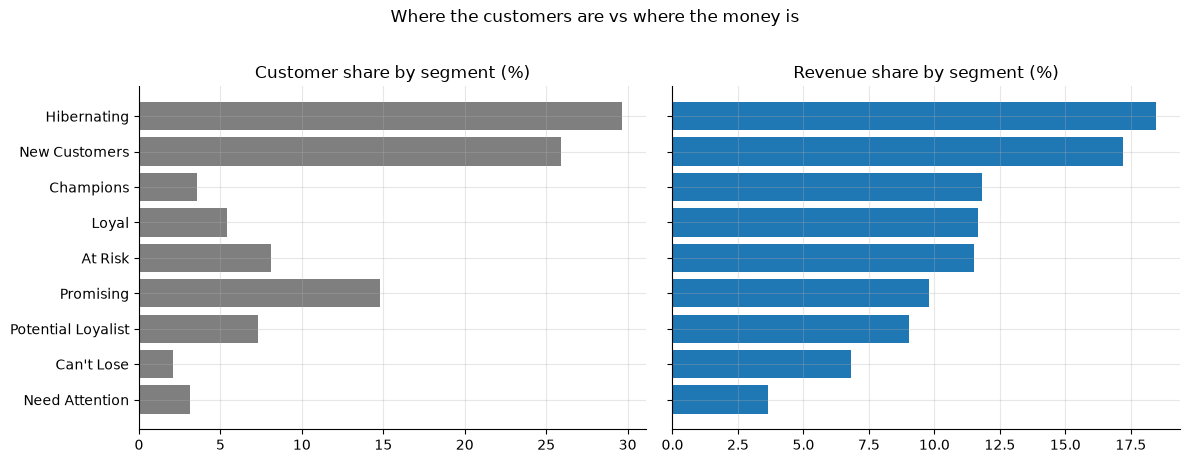

In [4]:
order = summary.index
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
ax[0].barh(order[::-1], summary['customer_share'][::-1] * 100, color=GRAY)
ax[0].set_title('Customer share by segment (%)')
ax[1].barh(order[::-1], summary['revenue_share'][::-1] * 100, color=BLUE)
ax[1].set_title('Revenue share by segment (%)')
fig.suptitle('Where the customers are vs where the money is', y=1.02)
fig.tight_layout()
fig.savefig(FIG / 'rfm_segment_sizes.png', bbox_inches='tight')
plt.show()

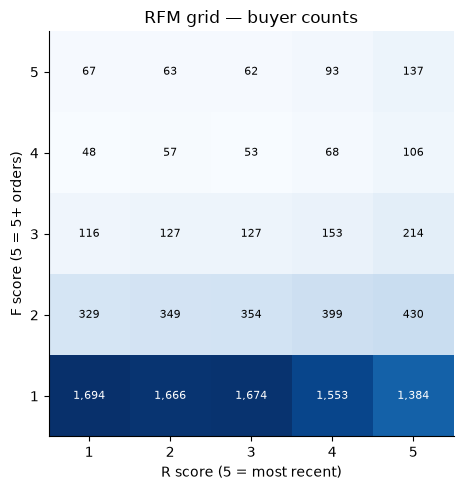

In [5]:
grid = rfm.pivot_table(index='F', columns='R', values='customer_id',
                       aggfunc='size', fill_value=0).sort_index(ascending=False)
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(grid, cmap='Blues')
ax.set_xticks(range(5), grid.columns)
ax.set_yticks(range(5), grid.index)
ax.set_xlabel('R score (5 = most recent)')
ax.set_ylabel('F score (5 = 5+ orders)')
ax.set_title('RFM grid — buyer counts')
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        v = grid.iloc[i, j]
        ax.text(j, i, f'{v:,}', ha='center', va='center',
                color='white' if v > grid.values.max() / 2 else 'black',
                fontsize=8)
ax.grid(False)
fig.tight_layout()
fig.savefig(FIG / 'rfm_heatmap.png', bbox_inches='tight')
plt.show()

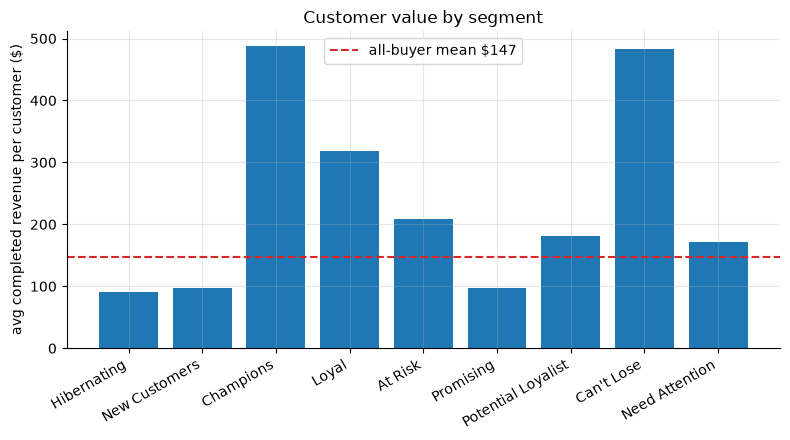

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(summary.index, summary['avg_revenue'], color=BLUE)
ax.axhline(rfm['monetary'].mean(), color=RED, ls='--',
           label=f"all-buyer mean ${rfm['monetary'].mean():.0f}")
ax.set_ylabel('avg completed revenue per customer ($)')
ax.set_title('Customer value by segment')
ax.legend()
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
fig.tight_layout()
fig.savefig(FIG / 'rfm_segment_value.png', bbox_inches='tight')
plt.show()

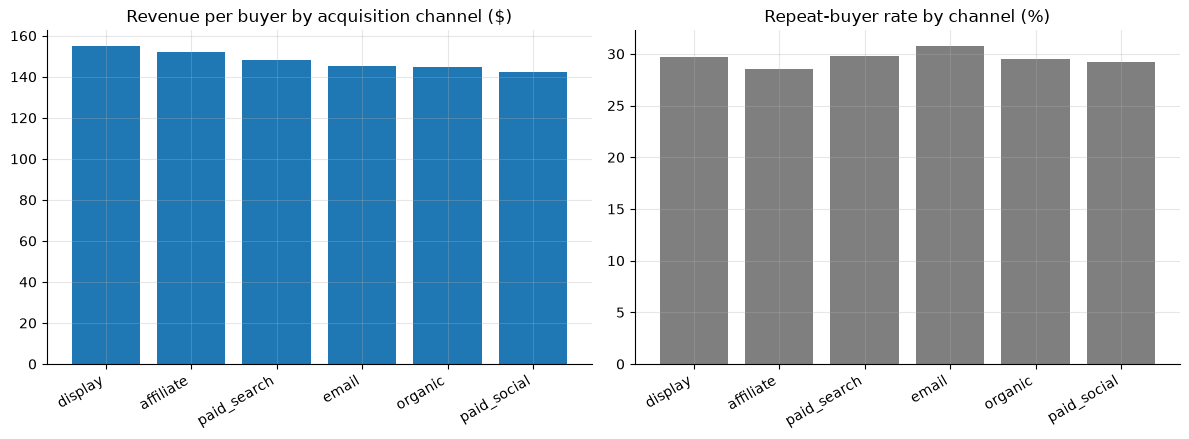

             buyers    revenue  repeat_rate  rev_per_buyer
channel                                                   
display        1517  234970.76        0.297        154.892
affiliate       924  140391.37        0.286        151.939
paid_search    2458  364675.54        0.298        148.363
email          1363  197672.43        0.307        145.027
organic        2779  402297.62        0.295        144.763
paid_social    2282  324805.41        0.292        142.334


In [7]:
chan = (rfm.groupby('channel')
        .agg(buyers=('customer_id', 'size'), revenue=('monetary', 'sum'),
             repeat_rate=('frequency', lambda s: (s > 1).mean()))
        .assign(rev_per_buyer=lambda d: d.revenue / d.buyers)
        .sort_values('rev_per_buyer', ascending=False))
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].bar(chan.index, chan['rev_per_buyer'], color=BLUE)
ax[0].set_title('Revenue per buyer by acquisition channel ($)')
ax[1].bar(chan.index, chan['repeat_rate'] * 100, color=GRAY)
ax[1].set_title('Repeat-buyer rate by channel (%)')
for a in ax:
    plt.setp(a.get_xticklabels(), rotation=30, ha='right')
fig.tight_layout()
fig.savefig(FIG / 'rfm_channel_value.png', bbox_inches='tight')
plt.show()
print(chan.round(3).to_string())

## Validation — tie back to the M3 gold gate

Totals must equal the warehouse numbers or this notebook fails on execution.

In [8]:
from sqlalchemy import text

with engine.connect() as conn:
    buyer_count = conn.execute(text(
        'SELECT MAX(buyer_count) FROM gold_customer_pareto')).scalar_one()
    gold_rev = float(conn.execute(text(
        'SELECT SUM(revenue) FROM gold_monthly_kpis')).scalar_one())

assert len(rfm) == buyer_count, (len(rfm), buyer_count)
assert abs(rfm['monetary'].sum() - gold_rev) < 0.01, (
    rfm['monetary'].sum(), gold_rev)
assert len(rfm) == summary['customers'].sum()

print(f"buyers                 {len(rfm):,} (= gold_customer_pareto)")
print(f"revenue total          ${rfm['monetary'].sum():,.2f} (= gold_monthly_kpis)")
print(f"one-order buyers (F=1) {(rfm['frequency'] == 1).mean():.1%}")
print(f"segments               {rfm['segment'].nunique()}")
print('figures ->', sorted(p.name for p in FIG.glob('rfm_*.png')))

buyers                 11,323 (= gold_customer_pareto)
revenue total          $1,664,813.13 (= gold_monthly_kpis)
one-order buyers (F=1) 70.4%
segments               9
figures -> ['rfm_channel_value.png', 'rfm_heatmap.png', 'rfm_segment_sizes.png', 'rfm_segment_value.png']
